In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [2]:
df = pd.read_csv(fr'data/3D/turb_Ek_nq=30.csv', header=0)
k = df['k'].tolist()
Ek = df['Ek'].tolist() 

df = pd.read_csv(fr'data/3D/turb_Es_nq=30.csv', header=0)
k = df['k'].tolist()
Es1 = df['Es1'].tolist() 
Es2 = df['Es2'].tolist() 
Es3 = df['Es3'].tolist() 

N = 2**10

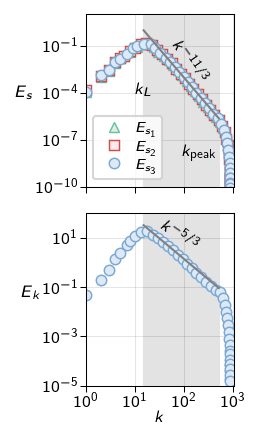

In [16]:
fig_width = 15/2.54
fig_height = 15/2.54
fig = plt.figure(figsize=(fig_width, fig_height))

ax_width = 2.5/2.54 / fig_width
ax_height = ax_width / 3 * 3.5
cbar_length = 1/2.54 / fig_width
cbar_width = 1.2/8/2.54 / fig_width

# 
ax = fig.add_axes([0, 0, ax_width, ax_height])

ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)
ax.loglog(k, Es1, linestyle='none', marker='^', markersize=5, markevery=(0, 0.03), markerfacecolor='#dfeddc', markeredgecolor='#66c2a5', alpha=1, markeredgewidth=0.7, label=r'$E_{s_1}$')
ax.loglog(k, Es2, linestyle='none', marker='s', markersize=5, markevery=(0.03/2, 0.03), markerfacecolor='#FFE9F1', markeredgecolor='#CE5044', alpha=1, markeredgewidth=0.7, label=r'$E_{s_2}$')
ax.loglog(k, Es3, linestyle='none', marker='o', markersize=5, markevery=(0.03/2, 0.03), markerfacecolor='#DDE9F5', markeredgecolor='#7AA7D3', alpha=1, markeredgewidth=0.7, label=r'$E_{s_3}$')
ax.loglog(np.linspace(15, 512, 100), 2e4*np.linspace(15, 512, 100)**(-11/3), linestyle='-', linewidth=1, color='grey')
ax.text(50, 5e-4, r'$k^{-11/3}$', rotation=-55)
ax.text(10, 1e-4, r'$k_L$')
ax.text(90, 1e-8, r'$k_{\mathrm{peak}}$')
# ax.text(2.5, 1e-7, r'$k^2$', rotation=0)
# ax.text(50, 1e-7, r'$\mathrm{e}^{-k/2}$', rotation=0)
ax.axvspan(xmin=15, xmax=512, color='#E3E3E3')
ax.legend(ncol=1, frameon=True, labelspacing=0.2, handlelength=2, handletextpad=0.5, bbox_to_anchor=(0, 0), loc='lower left', fontsize=fontsize-1)
plt.xlim(1, N)
plt.ylim(1e-10, 1e1)
# plt.xlabel(r'$k$', labelpad=0, size=fontsize)
plt.ylabel(r'$E_s$', rotation=0, labelpad=6, size=fontsize)
ax.set_xticks([1e0, 1e1, 1e2, 1e3])
ax.set_xticklabels([])
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=1.5, width=0.5)


# 
ax = fig.add_axes([0, -ax_height-0.03, ax_width, ax_height])
ax.grid(color='k', linestyle='-', linewidth=0.5, alpha=0.1)
ax.loglog(k, Ek, linestyle='none', marker='o', markersize=5, markevery=(0.03/2, 0.03), markerfacecolor='#DDE9F5', markeredgecolor='#7AA7D3', markeredgewidth=0.7)
ax.loglog(np.linspace(15, 512, 100), 3e3*np.linspace(15, 512, 100)**(-5/3), linestyle='-', linewidth=1, color='grey')
ax.text(30, 3, r'$k^{-5/3}$', rotation=-35)
ax.axvspan(xmin=15, xmax=512, color='#E3E3E3')
# ax.text(2.5, 1e-7, r'$k^2$', rotation=0)
# ax.text(50, 1e-7, r'$\mathrm{e}^{-k/2}$', rotation=0)
plt.xlim(1, N)
plt.ylim(1e-5, 1e2)
plt.xlabel(r'$k$', labelpad=0, size=fontsize)
plt.ylabel(r'$E_k$', rotation=0, labelpad=6, size=fontsize)
ax.set_xticks([1e0, 1e1, 1e2, 1e3])
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(axis='x', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1.5)
ax.tick_params(axis='y', which='major', direction='out', top=False, right=False, length=3, width=0.5, pad=1)
ax.tick_params(which='minor', direction='out', top=False, right=False, length=1.5, width=0.5)


# 
plt.savefig(fr'figures/spectrum.pdf', transparent=True, orientation='portrait', format='pdf', bbox_inches='tight')
